# Regression Analysis – Customer Spending Prediction

## Objective
Predict the continuous `Total_Spending` value of a customer using demographic and engagement features.

This is a separate regression task added to the project so the overall project demonstrates **classification + regression + clustering**.

### Target
- `Total_Spending`

### Input features
- `Income`
- `Age`
- `Recency`
- `NumWebPurchases`
- `NumStorePurchases`
- `NumWebVisitsMonth`

The regression target is continuous, so regression metrics such as MAE, MSE, RMSE and R² are used.

In [8]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)


In [9]:
# Load dataset using a path that works when this notebook is inside notebooks/
DATA_PATH = os.path.join('..', 'data', 'customer_segmentation.csv')

df = pd.read_csv(DATA_PATH)

# Create the engineered fields used by the regression task from the raw segmentation dataset
if 'Age' not in df.columns:
    df['Age'] = 2026 - df['Year_Birth']

if 'Total_Spending' not in df.columns:
    spend_cols = [
        'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
        'MntSweetProducts', 'MntGoldProds'
    ]
    df['Total_Spending'] = df[spend_cols].sum(axis=1)

print('Dataset shape:', df.shape)
display(df.head())


Dataset shape: (2240, 31)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Spending
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,69,1617
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,72,27
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,61,776
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,42,53
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,45,422


## 1. Data Preparation

We check the selected columns, missing values and duplicate records before modelling.

In [10]:
features = [
    'Income',
    'Age',
    'Recency',
    'NumWebPurchases',
    'NumStorePurchases',
    'NumWebVisitsMonth'
]
target = 'Total_Spending'

required_columns = features + [target]
missing_columns = [c for c in required_columns if c not in df.columns]

if missing_columns:
    raise ValueError(f'Missing required columns: {missing_columns}')

print('Missing values:')
print(df[required_columns].isnull().sum())
print('\nDuplicate rows:', df.duplicated().sum())

reg_df = df[required_columns].copy()
reg_df = reg_df.dropna()

print('\nRegression dataset shape after cleaning:', reg_df.shape)


Missing values:
Income               24
Age                   0
Recency               0
NumWebPurchases       0
NumStorePurchases     0
NumWebVisitsMonth     0
Total_Spending        0
dtype: int64

Duplicate rows: 0

Regression dataset shape after cleaning: (2216, 7)


In [11]:
# Quick descriptive statistics
display(reg_df.describe().T)


,count,mean,std,min,25%,50%,75%,max
Income,2216.0,52247.251354,25173.076661,1730.0,35303.0,51381.5,68522.0,666666.0
Age,2216.0,57.179603,11.985554,30.0,49.0,56.0,67.0,133.0
Recency,2216.0,49.012635,28.948352,0.0,24.0,49.0,74.0,99.0
NumWebPurchases,2216.0,4.085289,2.740951,0.0,2.0,4.0,6.0,27.0
NumStorePurchases,2216.0,5.800993,3.250785,0.0,3.0,5.0,8.0,13.0
NumWebVisitsMonth,2216.0,5.319043,2.425359,0.0,3.0,6.0,7.0,20.0
Total_Spending,2216.0,607.075361,602.900476,5.0,69.0,396.5,1048.0,2525.0


## 2. Train-Test Split

The data is split into 80% training and 20% testing data. The test set is kept separate for final evaluation.

In [12]:
X = reg_df[features]
y = reg_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print('Training samples:', X_train.shape[0])
print('Testing samples :', X_test.shape[0])


Training samples: 1772
Testing samples : 444


## 3. Model 1 – Linear Regression

Linear Regression provides a simple baseline for predicting the continuous spending target.

In [13]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_pred)
linear_mse = mean_squared_error(y_test, linear_pred)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, linear_pred)

print('Linear Regression')
print(f'MAE  : {linear_mae:.2f}')
print(f'MSE  : {linear_mse:.2f}')
print(f'RMSE : {linear_rmse:.2f}')
print(f'R²   : {linear_r2:.4f}')


Linear Regression
MAE  : 274.90
MSE  : 153266.84
RMSE : 391.49
R²   : 0.6242


## 4. Model 2 – Random Forest Regression

Random Forest Regression is used to capture nonlinear relationships between customer characteristics and spending.

In [14]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print('Random Forest Regression')
print(f'MAE  : {rf_mae:.2f}')
print(f'MSE  : {rf_mse:.2f}')
print(f'RMSE : {rf_rmse:.2f}')
print(f'R²   : {rf_r2:.4f}')


Random Forest Regression
MAE  : 157.43
MSE  : 76069.57
RMSE : 275.81
R²   : 0.8135


## 5. Model Comparison

For MAE, MSE and RMSE, lower values are better. For R², higher values are better.

In [15]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regressor'],
    'MAE': [linear_mae, rf_mae],
    'MSE': [linear_mse, rf_mse],
    'RMSE': [linear_rmse, rf_rmse],
    'R2': [linear_r2, rf_r2]
})

display(results.round(4))

best_model_name = results.loc[results['R2'].idxmax(), 'Model']
print('Best model based on test R²:', best_model_name)


,Model,MAE,MSE,RMSE,R2
0,Linear Regression,274.9038,153266.8393,391.4931,0.6242
1,Random Forest Regressor,157.4337,76069.5668,275.8071,0.8135


Best model based on test R²: Random Forest Regressor


## 6. Actual vs Predicted Values

The plot compares the actual spending values with the predictions produced by the better-performing model.

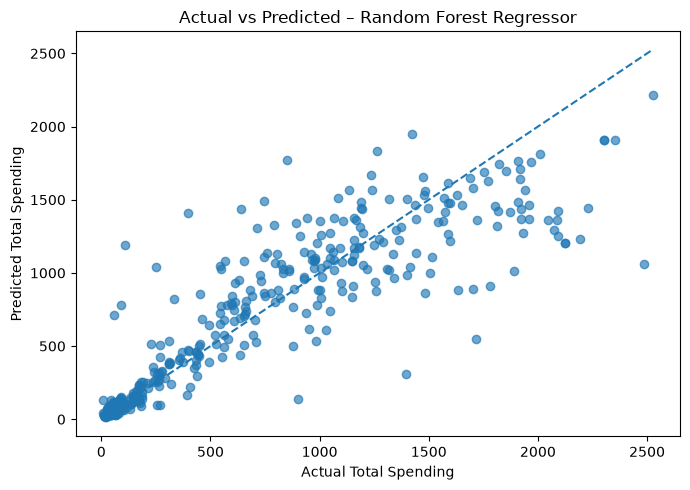

In [16]:
if rf_r2 >= linear_r2:
    best_model = rf_model
    best_pred = rf_pred
    best_model_label = 'Random Forest Regressor'
else:
    best_model = linear_model
    best_pred = linear_pred
    best_model_label = 'Linear Regression'

plt.figure(figsize=(7, 5))
plt.scatter(y_test, best_pred, alpha=0.65)
line_min = min(y_test.min(), best_pred.min())
line_max = max(y_test.max(), best_pred.max())
plt.plot([line_min, line_max], [line_min, line_max], linestyle='--')
plt.xlabel('Actual Total Spending')
plt.ylabel('Predicted Total Spending')
plt.title(f'Actual vs Predicted – {best_model_label}')
plt.tight_layout()
plt.show()


## 7. Residual Analysis

Residuals are the differences between actual and predicted values. A residual plot helps identify systematic prediction errors.

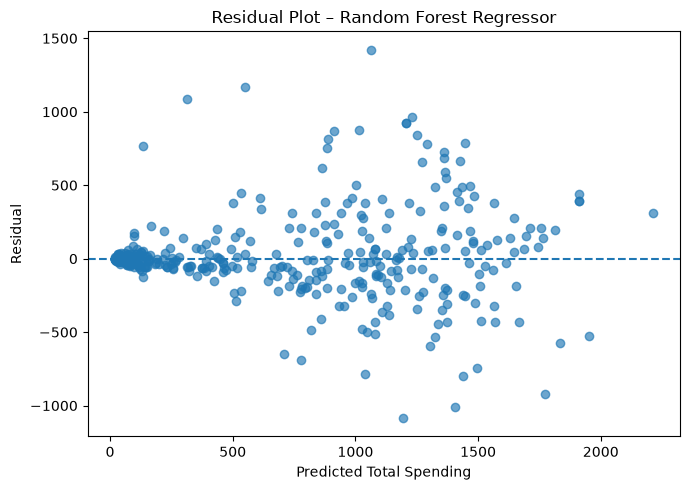

In [17]:
residuals = y_test - best_pred

plt.figure(figsize=(7, 5))
plt.scatter(best_pred, residuals, alpha=0.65)
plt.axhline(0, linestyle='--')
plt.xlabel('Predicted Total Spending')
plt.ylabel('Residual')
plt.title(f'Residual Plot – {best_model_label}')
plt.tight_layout()
plt.show()


## 8. Feature Importance

If Random Forest is selected as the better model, its feature importances are examined to understand which variables contributed most to prediction.

,Feature,Importance
0,Income,0.727368
4,NumStorePurchases,0.118581
3,NumWebPurchases,0.054091
2,Recency,0.035865
1,Age,0.035678
5,NumWebVisitsMonth,0.028416


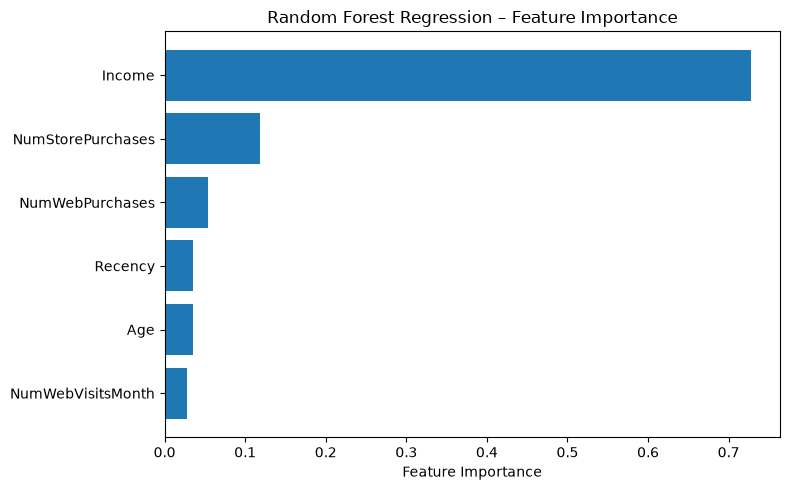

In [18]:
if best_model_label == 'Random Forest Regressor':
    importance_df = pd.DataFrame({
        'Feature': features,
        'Importance': rf_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    display(importance_df)

    plt.figure(figsize=(8, 5))
    plt.barh(importance_df['Feature'], importance_df['Importance'])
    plt.gca().invert_yaxis()
    plt.xlabel('Feature Importance')
    plt.title('Random Forest Regression – Feature Importance')
    plt.tight_layout()
    plt.show()
else:
    print('Random Forest was not the selected model, so feature importance is not displayed.')


## 9. Save the Best Regression Model

The selected model is saved so it can be reused for inference without retraining.

In [19]:
MODEL_DIR = os.path.join('..', 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(best_model, os.path.join(MODEL_DIR, 'best_spending_regressor.pkl'))
print('Saved:', os.path.join(MODEL_DIR, 'best_spending_regressor.pkl'))


Saved: ../models/best_spending_regressor.pkl


## 10. Final Interpretation

This regression analysis adds a supervised learning task with a continuous target to the project. The project now demonstrates:

1. **Classification:** credit risk prediction (Good/Bad).
2. **Regression:** prediction of continuous customer Total Spending.
3. **Clustering:** K-Means customer segmentation into six behavioral groups.

The regression results should be reported using the actual values generated by this notebook. Do not enter invented metrics into the report or presentation.